# Models evaluation

Celem tego notebooka jest przygotowanie i porównanie trzech modeli klasyfikacyjnych przewidujących ryzyko cukrzycy na podstawie danych diagnostycznych.

W projekcie wykorzystano trzy modele:
- Logistic Regression,
- Random Forest,
- SVC.

Logistic Regression pełni rolę modelu interpretowalnego z natury, natomiast Random Forest i SVC są modelami bardziej złożonymi. Modele porównano za pomocą kilku metryk jakości, takich jak accuracy, balanced accuracy, precision, recall, F1 oraz ROC AUC.

Celem jest porównanie jakości modeli w zadaniu klasyfikacji ryzyka cukrzycy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df_clean = df.copy()

for col in zero_columns:
    df_clean = df_clean[df_clean[col] != 0]


In [4]:
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

Dane podzielono na zbiór treningowy i testowy w proporcji 80/20. Zastosowano `stratify=y`, aby zachować podobny rozkład klas w obu zbiorach. 

## Model 1: Logistic Regression

In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline_logistic = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

pipeline_logistic.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [8]:
y_pred_logistic = pipeline_logistic.predict(X_test)

## Accuracy

In [9]:
from sklearn.metrics import accuracy_score

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

accuracy_logistic

0.8354430379746836

Model Logistic Regression uzyskał accuracy na poziomie około 0.84, co oznacza, że poprawnie sklasyfikował około 84% obserwacji ze zbioru testowego.

## Confusion matrix

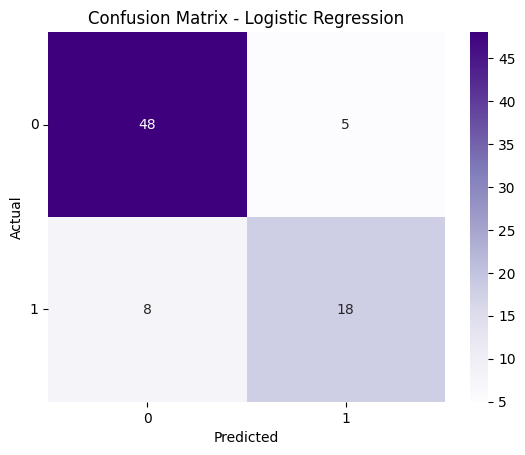

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_logistic)

sns.heatmap(
    pd.DataFrame(cm),
    annot=True,       # liczby w komórkach
    fmt='d',          # format liczb (integer)
    cmap='Purples'
)

plt.yticks(rotation=0)   # etykiety osi Y pionowo
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

Macierz pomyłek pokazuje, że model Logistic Regression lepiej rozpoznaje klasę 0 niż klasę 1. Jest to widoczne po wyższym recall dla klasy 0 oraz niższym recall dla klasy 1.

## Classification report

In [11]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.86      0.91      0.88        53
           1       0.78      0.69      0.73        26

    accuracy                           0.84        79
   macro avg       0.82      0.80      0.81        79
weighted avg       0.83      0.84      0.83        79



## ROC AUC - Logistic regression

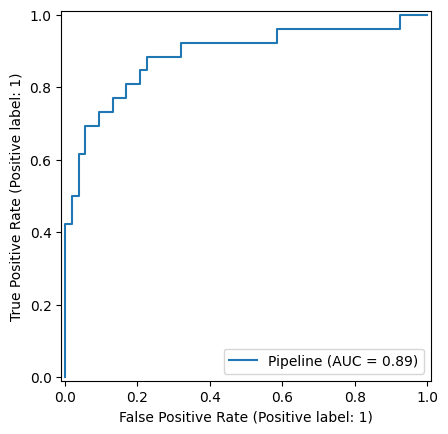

In [12]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

roc_auc_logistic = roc_auc_score(y_test, pipeline_logistic.predict_proba(X_test)[:, 1])
RocCurveDisplay.from_estimator(pipeline_logistic, X_test, y_test)
plt.show()

Krzywa ROC znajduje się wyraźnie powyżej przekątnej, a wartość AUC wynosi około 0.89. Oznacza to, że model ma dobrą zdolność odróżniania przypadków cukrzycy od przypadków braku cukrzycy.

## Model 2: Random Forest

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [14]:
pipeline_rf = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

pipeline_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If 

In [15]:
y_pred_rf = pipeline_rf.predict(X_test)

## Accuracy - Random Forest

In [16]:
from sklearn.metrics import accuracy_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)

accuracy_rf

0.8354430379746836

## Confusion matrix - Random Forest

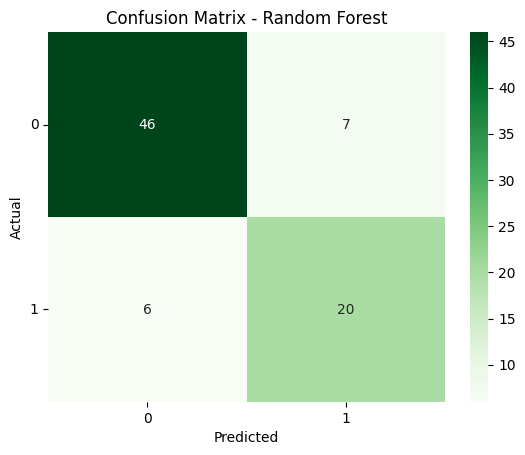

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(
    pd.DataFrame(cm_rf),
    annot=True,       # liczby w komórkach
    fmt='d',          # format liczb (integer)
    cmap='Greens'
)

plt.yticks(rotation=0)   # etykiety osi Y pionowo
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

Macierz pomyłek dla modelu Random Forest pokazuje, że model poprawnie rozpoznał 46 przypadków klasy 0 oraz 20 przypadków klasy 1. Model popełnił 7 błędów false positive, czyli przewidział cukrzycę u osób bez cukrzycy, oraz 6 błędów false negative, czyli nie wykrył cukrzycy u osób należących do klasy 1.

W porównaniu z Logistic Regression model Random Forest poprawnie wykrył więcej przypadków klasy 1 i popełnił mniej błędów false negative. Oznacza to, że lepiej radził sobie z wykrywaniem rzeczywistych przypadków cukrzycy.

## Classification report - Random Forest

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.87      0.88        53
           1       0.74      0.77      0.75        26

    accuracy                           0.84        79
   macro avg       0.81      0.82      0.82        79
weighted avg       0.84      0.84      0.84        79



## ROC AUC - Random Forest

ROC AUC: 0.86066763425254


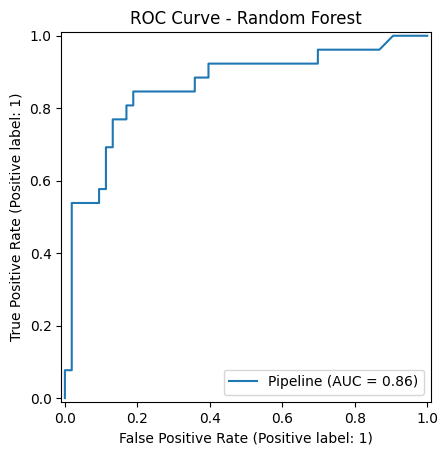

In [19]:
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print("ROC AUC:", roc_auc_rf)

RocCurveDisplay.from_estimator(
    pipeline_rf,
    X_test,
    y_test
)

plt.title("ROC Curve - Random Forest")
plt.show()

Krzywa ROC znajduje się wyraźnie powyżej przekątnej, a wartość ROC AUC wyniosła około 0.86. Oznacza to, że model dobrze rozróżnia klasę 0 i klasę 1.

## Model 3: Support Vector Classifier

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

pipeline_svc = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear", probability=True))
])

pipeline_svc.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


In [21]:
y_pred_svc = pipeline_svc.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score

accuracy_svc = accuracy_score(y_test, y_pred_svc)
accuracy_svc

0.8481012658227848

ROC AUC: 0.8730043541364296


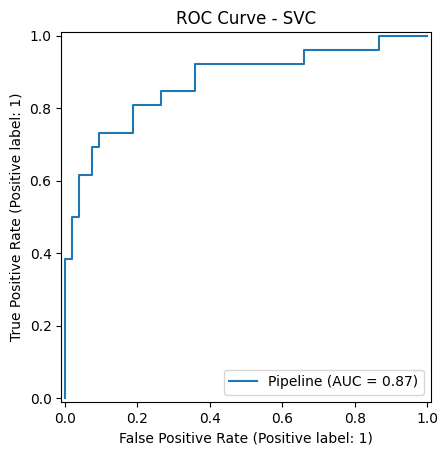

In [23]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

y_proba_svc = pipeline_svc.predict_proba(X_test)[:, 1]

roc_auc_svc = roc_auc_score(y_test, y_proba_svc)

print("ROC AUC:", roc_auc_svc)

RocCurveDisplay.from_estimator(
    pipeline_svc,
    X_test,
    y_test
)

plt.title("ROC Curve - SVC")
plt.show()

Model SVC uzyskał najwyższą wartość accuracy oraz precision spośród analizowanych modeli. Oznacza to, że na pojedynczym podziale train/test osiągnął najlepszą ogólną skuteczność oraz najrzadziej mylił się wtedy, gdy przewidywał klasę 1, czyli cukrzycę.

Jednocześnie recall dla SVC był niższy niż w przypadku Random Forest. Oznacza to, że SVC wykrywał mniej rzeczywistych przypadków cukrzycy niż Random Forest. Z tego względu, mimo wysokiej accuracy, Random Forest pozostaje istotnym modelem do dalszej analizy, szczególnie że w problemach medycznych ważne jest nie tylko ogólne trafienie, ale także wykrywanie przypadków klasy pozytywnej.

SVC został wykorzystany jako model porównawczy. Szczegółową analizę XAI skoncentrowano na Logistic Regression oraz Random Forest, ponieważ pierwszy model jest interpretowalny z natury, a drugi jako model złożony dobrze nadaje się do metod post-hoc.

In [24]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred_logistic),
        "Balanced accuracy": balanced_accuracy_score(y_test, y_pred_logistic),
        "Precision": precision_score(y_test, y_pred_logistic),
        "Recall": recall_score(y_test, y_pred_logistic),
        "F1": f1_score(y_test, y_pred_logistic),
        "ROC AUC": roc_auc_score(
            y_test,
            pipeline_logistic.predict_proba(X_test)[:, 1]
        )
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Balanced accuracy": balanced_accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1": f1_score(y_test, y_pred_rf),
        "ROC AUC": roc_auc_score(
            y_test,
            pipeline_rf.predict_proba(X_test)[:, 1]
        )
    },
    {
        "Model": "SVC",
        "Accuracy": accuracy_score(y_test, y_pred_svc),
        "Balanced accuracy": balanced_accuracy_score(y_test, y_pred_svc),
        "Precision": precision_score(y_test, y_pred_svc),
        "Recall": recall_score(y_test, y_pred_svc),
        "F1": f1_score(y_test, y_pred_svc),
        "ROC AUC": roc_auc_score(
            y_test,
            pipeline_svc.predict_proba(X_test)[:, 1]
        )
    }
])

results_df

,Model,Accuracy,Balanced accuracy,Precision,Recall,F1,ROC AUC
0,Logistic Regression,0.835443,0.798984,0.782609,0.692308,0.734694,0.887518
1,Random Forest,0.835443,0.818578,0.740741,0.769231,0.754717,0.860668
2,SVC,0.848101,0.808418,0.818182,0.692308,0.750000,0.873004


## Walidacja krzyżowa

Stratified K-Fold (StratifiedKFold)
Zachowuje proporcje klas w każdym foldzie.
Zastosowanie: klasyfikacja z nierównymi klasami (imbalanced).
Bo mamy klasy 0 i 1 w nierównych proporcjach, więc chcemy, żeby w każdym foldzie była podobna proporcja osób z cukrzycą i bez cukrzycy.

In [27]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import pandas as pd

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000))
    ]),

    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]),

    "SVC": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="linear", probability=True))
    ])
}

In [29]:
cv_results = []

for name, model in cv_models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="roc_auc"
    )
    
    cv_results.append({
        "Model": name,
        "ROC AUC scores": scores,
        "Mean ROC AUC": scores.mean(),
        "Std ROC AUC": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,Model,ROC AUC scores,Mean ROC AUC,Std ROC AUC
0,Logistic Regression,"[0.8461538461538461, 0.8563134978229318, 0.883...",0.850257,0.020670
1,Random Forest,"[0.8207547169811321, 0.8486937590711175, 0.873...",0.856005,0.028907
2,SVC,"[0.8468795355587808, 0.8686502177068215, 0.882...",0.849023,0.023707


W walidacji krzyżowej wszystkie modele uzyskały zbliżone wyniki ROC AUC, na poziomie około 0.85. Najwyższy średni wynik osiągnął model Random Forest, jednak różnice między modelami były niewielkie. Oznacza to, że modele mają podobną zdolność rozróżniania klasy 0 i klasy 1.

Niskie wartości odchylenia standardowego wskazują, że wyniki były dość stabilne między podziałami danych. Walidacja krzyżowa potwierdza więc, że modele nie uzyskały dobrego wyniku wyłącznie przez przypadkowy pojedynczy podział train/test.

## Podsumowanie

W tej części projektu wytrenowano i oceniono trzy modele klasyfikacyjne: Logistic Regression, Random Forest oraz SVC. Wszystkie modele uzyskały dobre i zbliżone wyniki, jednak różniły się pod względem poszczególnych metryk.

Na pojedynczym podziale train/test najwyższą wartość accuracy osiągnął model SVC. Uzyskał również najwyższą wartość precision, co oznacza, że najrzadziej mylił się wtedy, gdy przewidywał klasę 1, czyli cukrzycę. Z kolei Random Forest osiągnął najwyższy recall oraz F1-score dla klasy 1, co oznacza, że najlepiej wykrywał rzeczywiste przypadki cukrzycy. Logistic Regression uzyskał najwyższą wartość ROC AUC na pojedynczym podziale train/test.

Walidacja krzyżowa pokazała, że różnice między modelami są niewielkie, a średnie wartości ROC AUC są zbliżone i wynoszą około 0.85. Najwyższy średni wynik ROC AUC w walidacji krzyżowej uzyskał Random Forest. Oznacza to, że model ten był stabilny i dobrze rozróżniał osoby z cukrzycą oraz bez cukrzycy.

Do dalszej analizy XAI wybrano przede wszystkim Logistic Regression oraz Random Forest. Logistic Regression jest modelem interpretowalnym z natury, dlatego można analizować jego współczynniki. Random Forest jest modelem bardziej złożonym, dlatego wymaga metod post-hoc, takich jak Permutation Importance, SHAP, LIME oraz PDP/ICE. Model SVC został wykorzystany jako model porównawczy.